In [1]:
import numpy as np
import cupy as cp
import matplotlib.pyplot as plt

from itertools import product
import os
import h5py
from tqdm import tqdm
import pandas as pd

#few utils
from few.utils.utility import get_p_at_t
from few.utils.constants import MTSUN_SI
from few.utils.geodesic import get_fundamental_frequencies
#few trajectory
from few.trajectory.inspiral import EMRIInspiral
from few.trajectory.ode.flux import SuperKludgeFlux
#few waveform
from few.waveform import FastKerrEccentricEquatorialFlux, GenerateEMRIWaveform
from few.waveform.waveform import SuperKludgeWaveform
from few.utils.constants import YRSID_SI

#sef imports
from stableemrifisher.fisher import StableEMRIFisher
from stableemrifisher.utils import generate_PSD, padding, inner_product
from stableemrifisher.fisher.derivatives import derivative
from stableemrifisher.fisher.stablederivative import StableEMRIDerivative
from stableemrifisher.noise import sensitivity_LWA

#lisa-on-gpu import
from fastlisaresponse import ResponseWrapper  # Response function 

#LISAanalysistools imports
from lisatools.detector import ESAOrbits, EqualArmlengthOrbits #ESAOrbits correspond to esa-trailing-orbits.h5, EqualArmlengthOrbits are equalarmlength-orbits.h5
from lisatools.sensitivity import get_sensitivity, A1TDISens, E1TDISens, T1TDISens
from lisatools.sensitivity import get_sensitivity,CornishLISASens

use_gpu = True
from parismc.sampler import SamplerConfig
from parismc.sampler import Sampler

from smt.sampling_methods import LHS

if not use_gpu:
    
    import few
    
    #tune few configuration
    cfg_set = few.get_config_setter(reset=True)
    cfg_set.enable_backends("cpu")
    cfg_set.set_log_level("info");

else:
    pass #let the backend decide for itself



if(use_gpu):
    xp=cp
else:
    xp=np

startup


In [2]:
#waveform class setup
waveform_class = SuperKludgeWaveform
max_step_days = 10.0 #max trajectory step size in days
inspiral_kwargs = {
    "err":1e-11, #default = 1e-11
    "max_step_size":max_step_days*24*60*60, #in seconds
    "use_gpu":use_gpu
}
sum_kwargs = {
    "pad_output": True, # True if expecting waveforms smaller than LISA observation window.
  #  "use_gpu":use_gpu
}
waveform_class_kwargs = dict(inspiral_kwargs=inspiral_kwargs,
                              mode_selector_kwargs=dict(mode_selection_threshold=1e-5),
                              sum_kwargs=sum_kwargs,
                              use_gpu=use_gpu)

waveform_generator = GenerateEMRIWaveform
waveform_generator_kwargs = dict(return_list=False)

     


In [3]:
m1 = 1e6
m2 = 1e1
a = 0.8
e0 = 0.4
xI0 = 1.0
dist = 0.5 
qS = np.pi/4
phiS = 1.0
qK = 1 
phiK = np.pi/3

Phi_phi0 = 0.9
Phi_theta0 =0.5
Phi_r0 = 0.4

dt = 10.0
T = 1.0

chi2 = 0.9

dev_C_p=0.0
dev_C_e=0.0


evolve_1PA = False
evolve_primary = False
evolve_2PA = False
deviation_included=True
p0=7.5

pars_list_snr = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0,\
              chi2,evolve_1PA,evolve_primary,evolve_2PA,deviation_included,dev_C_p,dev_C_e,]

pars_list = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]

pars_list_com = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0,\
             chi2,evolve_1PA,evolve_primary,evolve_2PA,deviation_included,dev_C_p,dev_C_e]

add_param_args={"chi2":chi2,"evolve_1PA":evolve_1PA,"evolve_primary":evolve_primary,"evolve_2PA":evolve_2PA,"deviation_included":deviation_included,"devCp":dev_C_p,
"devCe":dev_C_e}

emri_kwargs = {"T":T, "dt":dt}

should take p0 around for for true waveform:  7.506743573435625
separatrix p:  3.3636344376256564
[0.9, False, False, False, True, 0.0, 0.0]


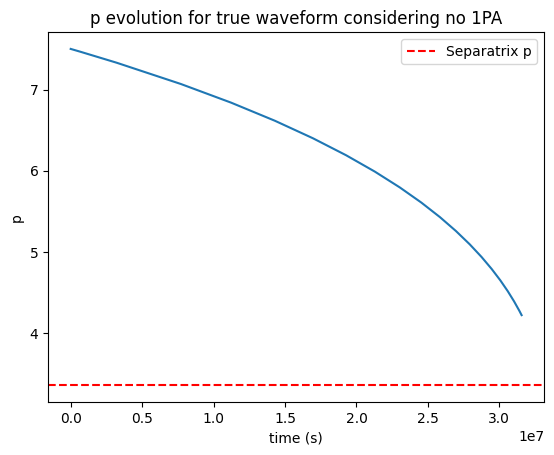

In [4]:
from few.utils.utility import ( 
    get_mismatch, 
    get_m2_at_t, 
    get_p_at_t, 
    )

from few.utils.geodesic import (
    get_fundamental_frequencies,
    get_separatrix, 
    get_kerr_geo_constants_of_motion,
    ELQ_to_pex,
    )
SK_traj = EMRIInspiral(func=SuperKludgeFlux)
#get_p_at_t may fail with SuperKludge, especially with lower eccentricities, so we use KerrEccEq to generate p0 
add_args = [chi2, evolve_1PA, evolve_primary, evolve_2PA,deviation_included,dev_C_p,dev_C_e]
p_sep = get_separatrix(a, e0, xI0)
p0_should = get_p_at_t(traj_module=SK_traj, t_out=T, traj_args=[m1, m2, a, e0, xI0, *add_args])
print('should take p0 around for for true waveform: ', p0_should+0.1)
print('separatrix p: ', p_sep)

from scipy.interpolate import CubicSpline
add_args = [chi2, evolve_1PA, evolve_primary, evolve_2PA,deviation_included,dev_C_p,dev_C_e]
print(add_args) 
t_evol, p_evol, e_evol, x2_evol, pp2_evol, pt2_evol, pr2_evol, _, _ = SK_traj(m1, m2, a, p0, e0, xI0, *add_args,
                                               Phi_phi0=Phi_phi0, Phi_theta0=Phi_theta0, Phi_r0=Phi_r0, T=T, dt=dt)
p_evolution = CubicSpline(t_evol, p_evol)(t_evol)
plt.plot(t_evol, p_evolution)
plt.title('p evolution for true waveform considering no 1PA')
plt.xlabel('time (s)')
plt.ylabel('p')
plt.axhline(p_sep, color='red', linestyle='--', label='Separatrix p')
plt.legend()
plt.show()

In [5]:
der_order = 8
Ndelta=10
sef = StableEMRIFisher(waveform_class=waveform_class, 
                       waveform_class_kwargs=waveform_class_kwargs,
                       waveform_generator=waveform_generator,
                       waveform_generator_kwargs=waveform_generator_kwargs,
                       stats_for_nerds = True, use_gpu = use_gpu,
                       deriv_type='stable',
                       noise_model=get_sensitivity,
                       noise_kwargs={'sens_fn':CornishLISASens,'return_type':'PSD'},
                       channels=["A","E"],
                       T = T, dt = dt,
                       stability_plot = False,
                       der_order = der_order, Ndelta = Ndelta,
                       plunge_check=True, return_derivatives=False
                       )
                   

SNR = sef.SNRcalc_SEF(*pars_list_com,**emri_kwargs,use_gpu=use_gpu)
print("SNR: ", SNR)
     


waveform shape: (2, 3155815)
wave ndim: 2
Computing SNR for parameters: (1000000.0, 10.0, 0.8, 7.5, 0.4, 1.0, 0.5, 0.7853981633974483, 1.0, 1, 1.0471975511965976, 0.9, 0.5, 0.4, 0.9, False, False, False, True, 0.0, 0.0)
SNR:  109.44007219850796


Body is not plunging, Fisher should be stable.
waveform shape: (2, 3155815)
wave ndim: 2
Computing SNR for parameters: (1000000.0, 10.0, 0.8, 7.5, 0.4, 1.0, 0.5, 0.7853981633974483, 1.0, 1, 1.0471975511965976, 0.9, 0.5, 0.4, 0.9, False, False, False, True, 0.0, 0.0)
Waveform Generated. SNR: 109.44007219850796
calculating stable deltas...
Gamma_ii for m1: 14234.061766844155
Gamma_ii for m1: 14234.061766501476
Gamma_ii for m1: 14234.061766817913
Gamma_ii for m1: 14234.061766254148
Gamma_ii for m1: 14234.061765562003
Gamma_ii for m1: 14234.061784697982
Gamma_ii for m1: 14234.06174564247
Gamma_ii for m1: 14234.06157704757
Gamma_ii for m1: 14234.060894848384
Gamma_ii for m1: 14234.06409513455
[np.float64(2.40746049409781e-11), np.float64(2.2230959707278878e-11), np.float64(3.9606744165305034e-11), np.float64(4.862599926376738e-11), np.float64(1.3443794060698078e-09), np.float64(2.7438065877817545e-09), np.float64(1.184446886352066e-08), np.float64(4.79272353494202e-08), np.float64(2.2483291

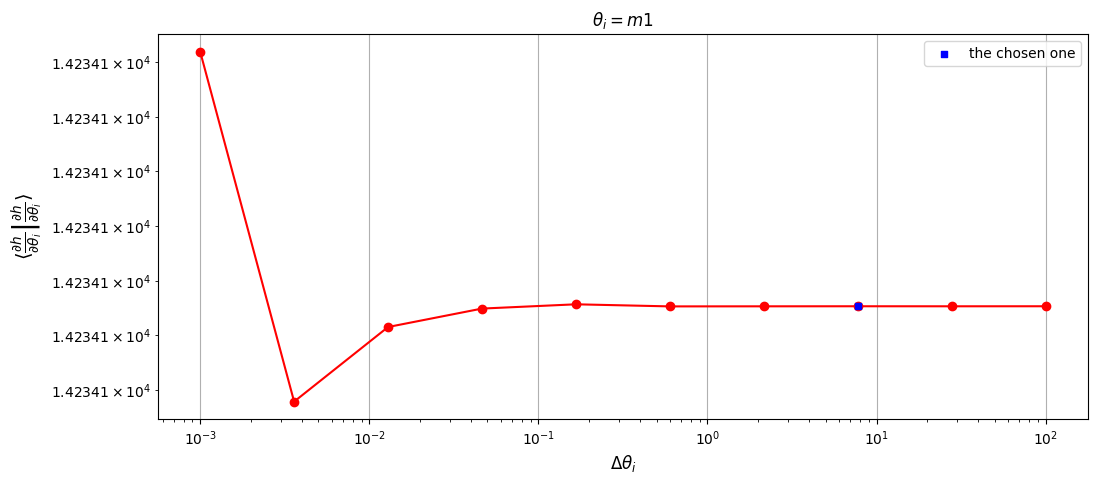

Gamma_ii for m2: 9076190702263.799
Gamma_ii for m2: 9076190701858.762
Gamma_ii for m2: 9076190703381.207
Gamma_ii for m2: 9076190697250.086
Gamma_ii for m2: 9076190710451.11
Gamma_ii for m2: 9076190701210.389
Gamma_ii for m2: 9076190687225.78
Gamma_ii for m2: 9076191388099.045
Gamma_ii for m2: 9076188073033.264
Gamma_ii for m2: 9076197826634.443
[np.float64(4.462633308179061e-11), np.float64(1.677405601375073e-10), np.float64(6.755169980736096e-10), np.float64(1.4544673926143047e-09), np.float64(1.018127649289329e-09), np.float64(1.5408016266871234e-09), np.float64(7.722107607206306e-08), np.float64(3.652486875078718e-07), np.float64(1.0746351463456636e-06)]
0


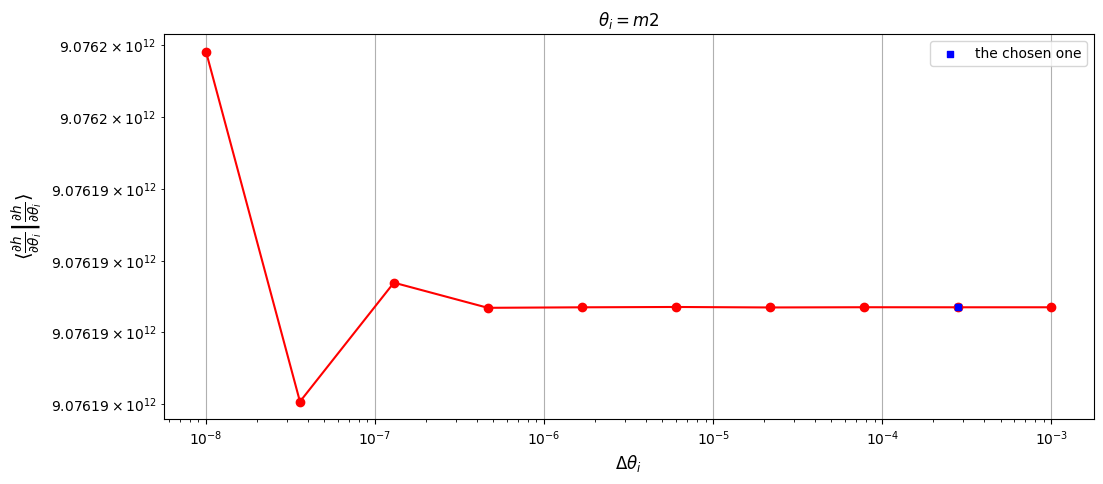

Gamma_ii for a: 1161643836786282.8
Gamma_ii for a: 1161643900819896.2
Gamma_ii for a: 1161644110935230.8
Gamma_ii for a: 1161641631489037.5
Gamma_ii for a: 1161656743620616.8
Gamma_ii for a: 1161632905771347.8
Gamma_ii for a: 1161729708446663.8
Gamma_ii for a: 1161542224237294.0
Gamma_ii for a: 1162657950371879.2
Gamma_ii for a: 1165687478742697.5
[np.float64(5.5123272678317885e-08), np.float64(1.808775446129002e-07), np.float64(2.134432966277e-06), np.float64(1.3009119657971393e-05), np.float64(2.052098313552093e-05), np.float64(8.332633194466019e-05), np.float64(0.0001614097236050615), np.float64(0.000959634030136191), np.float64(0.0025989198872461757)]
0


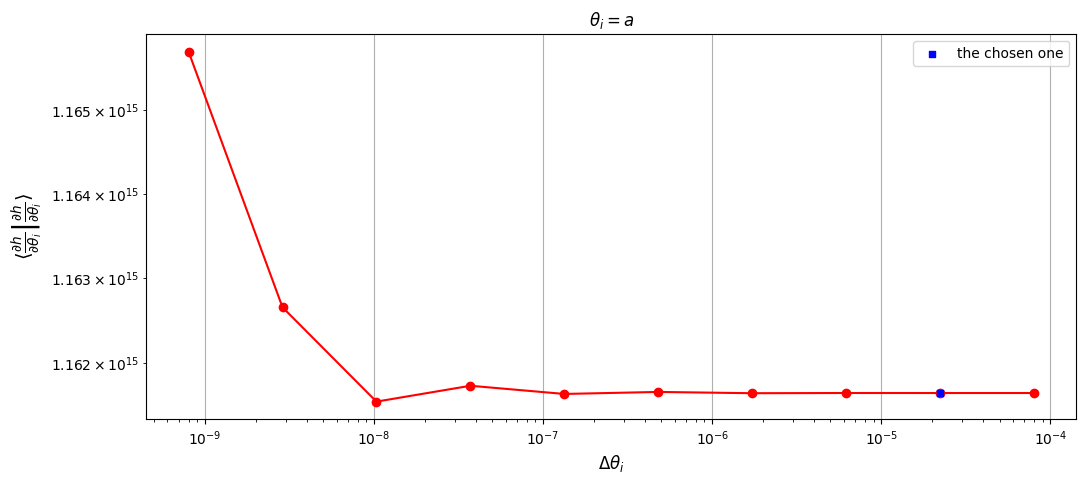

Gamma_ii for p0: 750321795658013.1
Gamma_ii for p0: 750321805981598.1
Gamma_ii for p0: 750321830212664.1
Gamma_ii for p0: 750322054220667.0
Gamma_ii for p0: 750320825138093.9
Gamma_ii for p0: 750323243450935.2
Gamma_ii for p0: 750322848966317.0
Gamma_ii for p0: 750338992681506.1
Gamma_ii for p0: 750338087124220.5
Gamma_ii for p0: 749796385603986.5
[np.float64(1.3758876415026101e-08), np.float64(3.2294230321317156e-08), np.float64(2.985491384864986e-07), np.float64(1.6380760495336001e-06), np.float64(3.223028024898361e-06), np.float64(5.257531725089568e-07), np.float64(2.1515228911977213e-05), np.float64(1.206865679837311e-06), np.float64(0.0007224648326327167)]
0


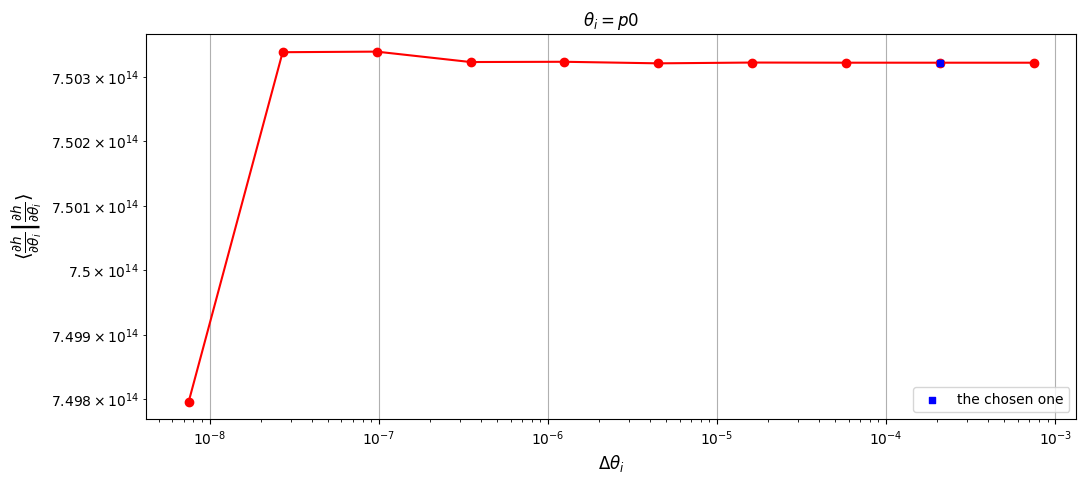

Gamma_ii for e0: 2442632232789683.0
Gamma_ii for e0: 2442632412872234.5
Gamma_ii for e0: 2442630556170600.5
Gamma_ii for e0: 2442624435830806.0
Gamma_ii for e0: 2442644808776543.5
Gamma_ii for e0: 2442605319148878.5
Gamma_ii for e0: 2442364436942643.0
Gamma_ii for e0: 2443144928540759.0
Gamma_ii for e0: 2440649331812228.5
Gamma_ii for e0: 2437744430395674.5
[np.float64(7.372478582982739e-08), np.float64(7.601238055872099e-07), np.float64(2.5056409428812982e-06), np.float64(8.340527310519729e-06), np.float64(1.6167011246319603e-05), np.float64(9.862664334280794e-05), np.float64(0.00031946184976515976), np.float64(0.0010225134336186968), np.float64(0.00119163493118206)]
0


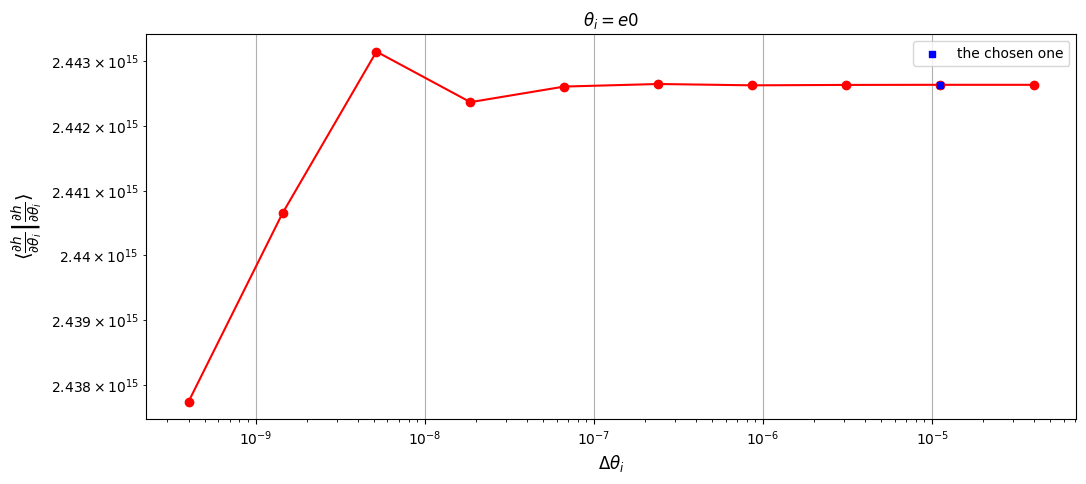

Gamma_ii for qS: 36777.61910724128
Gamma_ii for qS: 36777.61916879842
Gamma_ii for qS: 36777.61916880028
Gamma_ii for qS: 36777.61916880112
Gamma_ii for qS: 36777.61916879532
Gamma_ii for qS: 36777.619168790625
Gamma_ii for qS: 36777.61916872028
Gamma_ii for qS: 36777.6191688253
Gamma_ii for qS: 36777.619169497724
Gamma_ii for qS: 36777.619170155296
[np.float64(1.6737663317103271e-09), np.float64(5.0646159031716305e-14), np.float64(2.2751204252528293e-14), np.float64(1.5767573729798181e-13), np.float64(1.2760458037291246e-13), np.float64(1.9126838496863217e-12), np.float64(2.855572888528499e-12), np.float64(1.828346124666158e-11), np.float64(1.7879676830006847e-11)]
2


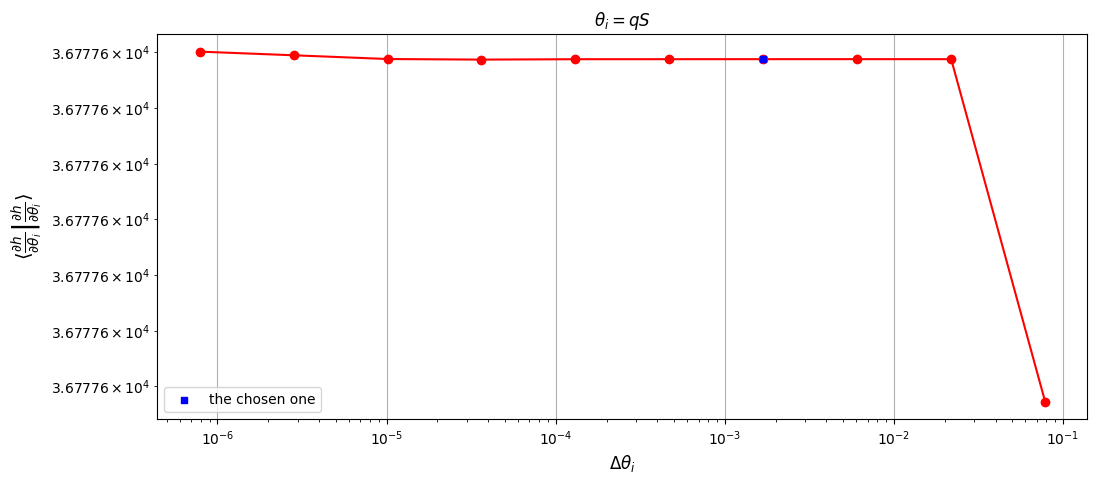

Gamma_ii for phiS: 709746.1172134423
Gamma_ii for phiS: 709746.1171902361
Gamma_ii for phiS: 709746.1171902353
Gamma_ii for phiS: 709746.1171902353
Gamma_ii for phiS: 709746.1171902353
Gamma_ii for phiS: 709746.117190235
Gamma_ii for phiS: 709746.1171902363
Gamma_ii for phiS: 709746.1171902377
Gamma_ii for phiS: 709746.117190205
Gamma_ii for phiS: 709746.1171902391
[np.float64(3.269652301142653e-11), np.float64(1.1481672573491822e-15), np.float64(0.0), np.float64(0.0), np.float64(4.920716817210784e-16), np.float64(1.9682867268843095e-15), np.float64(1.9682867268843056e-15), np.float64(4.609071418787628e-14), np.float64(4.805900091475836e-14)]
2


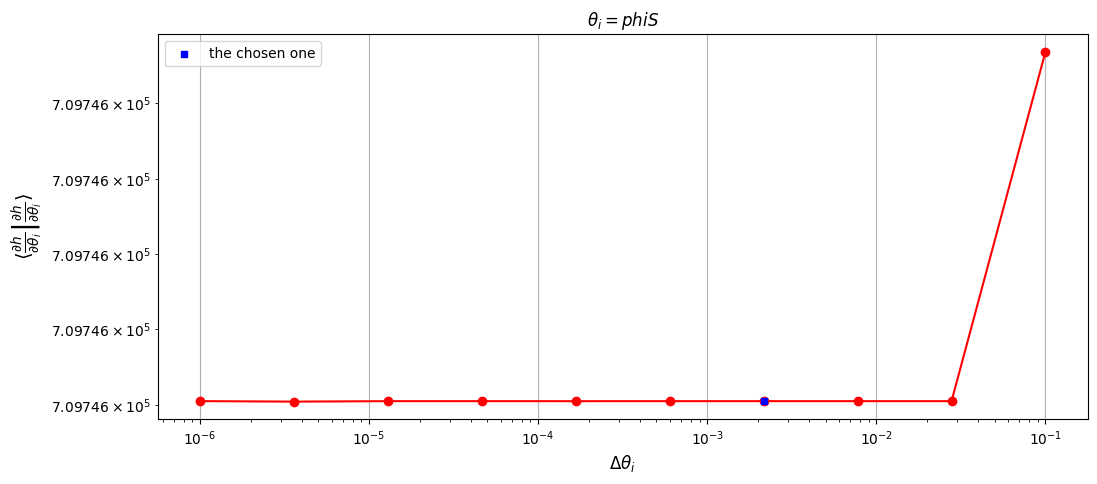

Gamma_ii for devCp: 5029.447574916534
Gamma_ii for devCp: 4961.063650408393
Gamma_ii for devCp: 6524.705367532515
Gamma_ii for devCp: 3505.7586104767456
Gamma_ii for devCp: 12524.969258562354
Gamma_ii for devCp: 106006.80648805141
Gamma_ii for devCp: 1537913.6696358866
Gamma_ii for devCp: 7785749.091358374
Gamma_ii for devCp: 35366628.61911679
Gamma_ii for devCp: 6750385129.119978
[np.float64(0.013784125608328259), np.float64(0.2396493985621075), np.float64(0.8611393688184439), np.float64(0.7200984259438299), np.float64(0.881847499481327), np.float64(0.9310710291604669), np.float64(0.802470686944836), np.float64(0.7798560565326284), np.float64(0.9947607983925908)]
0
minimum relative error is greater than 1% for devCp. Fisher may be unstable!


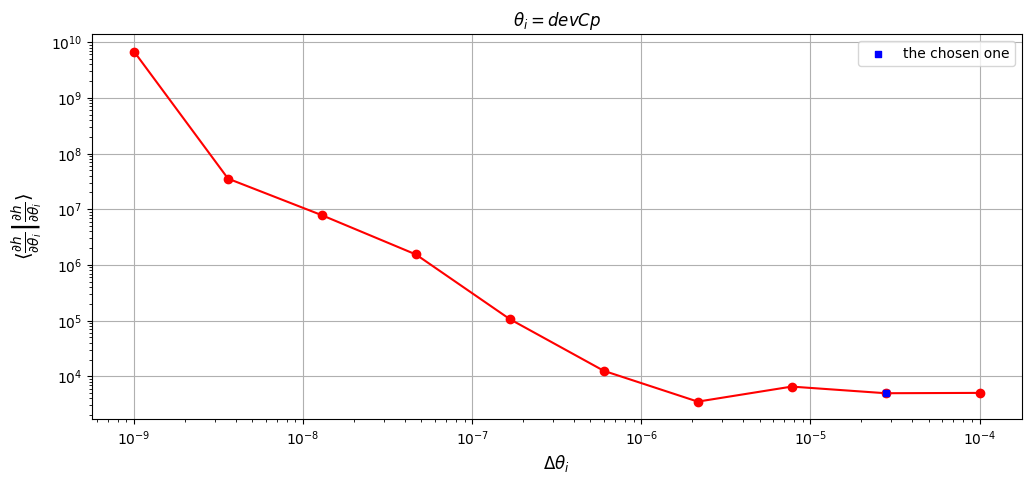

Gamma_ii for devCe: 32501.35787188868
Gamma_ii for devCe: 32943.787853840455
Gamma_ii for devCe: 31176.880382500913
Gamma_ii for devCe: 33982.8263829204
Gamma_ii for devCe: 92180.54464007511
Gamma_ii for devCe: 28316.659998299063
Gamma_ii for devCe: 2410230.9465353964
Gamma_ii for devCe: 13003354.446519474
Gamma_ii for devCe: 224536915.21819374
Gamma_ii for devCe: 10386493401.244833
[np.float64(0.013429845527013365), np.float64(0.05667364565222116), np.float64(0.08256952993850278), np.float64(0.631344916483098), np.float64(2.2553466632580346), np.float64(0.9882514743912806), np.float64(0.8146454473383576), np.float64(0.9420881219736922), np.float64(0.9783818362421256)]
0
minimum relative error is greater than 1% for devCe. Fisher may be unstable!


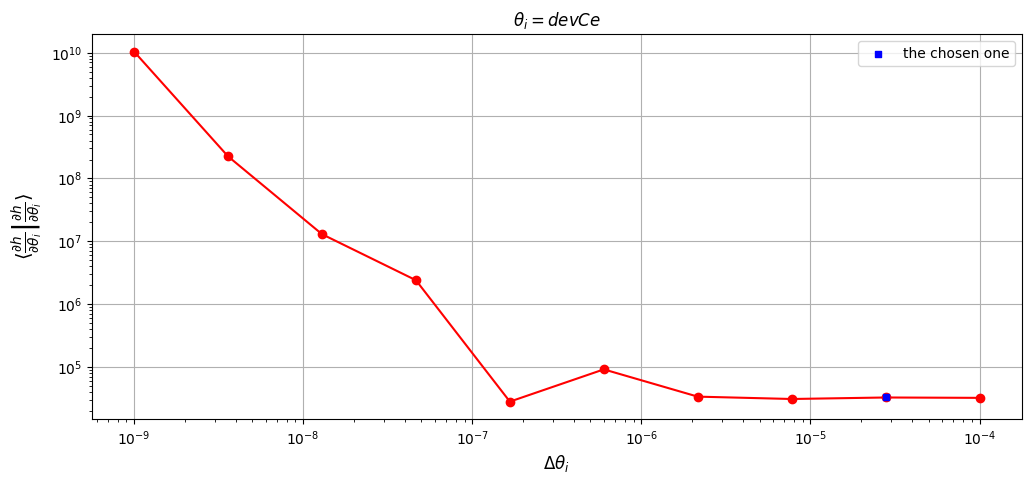

stable deltas: {'m1': 7.742636826811269, 'm2': 0.0002782559402207126, 'a': 2.2260475217657015e-05, 'p0': 0.00020869195516553445, 'e0': 1.1130237608828506e-05, 'qS': 0.0016920890487107918, 'phiS': 0.002154434690031882, 'Phi_phi0': 0.0, 'Phi_r0': 0.0, 'devCp': 2.782559402207126e-05, 'devCe': 2.782559402207126e-05}
Time taken to compute stable deltas is 203.14880061149597 seconds
calculating Fisher matrix...
Finished derivatives
Calculated Fisher is *atleast* positive-definite.
Time taken to compute FM is 21.45629644393921 seconds


In [6]:
#initialize the 0PA (approximate) model
evolve_1PA = False 
evolve_primary = False
evolve_2PA = False #for approximate model
deviation_included=True
add_param_args={"chi2":chi2,"evolve_1PA":evolve_1PA,"evolve_primary":evolve_primary,"evolve_2PA":evolve_2PA,"deviation_included":deviation_included,"devCp":dev_C_p,
"devCe":dev_C_e}


param_names = ['m1','m2','a','p0','e0','qS','phiS','Phi_phi0','Phi_r0','devCp','devCe']
pars_list = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]

param_dict = {
    'm1': m1,
    'm2': m2,
    'a': a,
    'p0': p0,
    'e0': e0,
    'xI0': xI0,
    'dist': dist,
    'qS': qS,
    'phiS': phiS,
    'qK': qK,
    'phiK': phiK,
    'Phi_phi0': Phi_phi0,
    'Phi_theta0': Phi_theta0,
    'Phi_r0': Phi_r0
}

Fisher = sef(wave_params = param_dict,param_names=param_names, add_param_args=add_param_args,
            live_dangerously = False, stability_plot = True,der_order = der_order, Ndelta = Ndelta,
            )

In [7]:
def logmasstransform(Fisher, m1, index_of_m1 = 0):    
    J = np.eye(len(Fisher))
    J[index_of_m1,index_of_m1] = m1
    
    return J.T@Fisher@J
fisher_=logmasstransform(Fisher, m1, index_of_m1 = 0)
cov=np.linalg.inv(fisher_)
std= np.sqrt(np.diag(cov))
params_truth_in = np.array([np.log(m1), m2, a, p0, e0, qS, phiS, Phi_phi0,Phi_r0,dev_C_p,dev_C_e])
     


In [8]:
chi2=0.9
deviation_included=True
evolve_1PA=True
evolve_primary=False
evolve_2PA=False
use_gpu=True
add_args = [chi2, evolve_1PA, evolve_primary, evolve_2PA,deviation_included,dev_C_p,dev_C_e]
superkludge_wave = GenerateEMRIWaveform(SuperKludgeWaveform,\
                                    sum_kwargs=sum_kwargs,\
                                    return_list=True,
                                    mode_selector_kwargs=dict(mode_selection_threshold=1e-5),
                                    inspiral_kwargs=inspiral_kwargs,
                                    use_gpu=use_gpu)
print(add_args)

waveform_true = superkludge_wave(m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0, *add_args, dt=dt, T=T)
PSD=generate_PSD(waveform_true,dt,use_gpu=use_gpu,
                noise_PSD=get_sensitivity,
                noise_kwargs={'sens_fn':CornishLISASens,'return_type':'PSD'},
                channels=["A","E"])
waveform_true=xp.array(waveform_true)
waveform_true

[0.9, True, False, False, True, 0.0, 0.0]


array([[ 6.07761801e-22,  5.28665123e-22,  4.16012822e-22, ...,
         1.54201176e-22,  3.24359266e-22,  4.68106663e-22],
       [-1.78779679e-22, -3.28868214e-22, -4.45252337e-22, ...,
         5.43380149e-22,  4.72605869e-22,  3.48178758e-22]],
      shape=(2, 3155815))

In [9]:
deviation_included=True
evolve_1PA=False
evolve_primary=False
evolve_2PA=False
add_args = [chi2, evolve_1PA, evolve_primary, evolve_2PA,deviation_included,dev_C_p,dev_C_e]

def loglike_calc(m1_, m2_, a_, p0_, e0_,qS_,phiS_,Phi_phi0_,Phi_r0_,dev_Cp_,dev_Ce_):
    add_args__ = [chi2, evolve_1PA, evolve_primary, evolve_2PA,deviation_included,dev_Cp_,dev_Ce_]
    waveform_temp=xp.array(superkludge_wave(m1_, m2_, a_, p0_, e0_, xI0, dist, qS_, phiS_, qK, phiK, Phi_phi0_, Phi_theta0, Phi_r0_, *add_args__, dt=dt, T=T,use_gpu=use_gpu))

    diff_inner=inner_product(waveform_true-waveform_temp,waveform_true-waveform_temp,PSD,dt,use_gpu=use_gpu)
    #print(diff_inner)
    return -0.5 * diff_inner

In [10]:
def log_density(params):
    params = np.asarray(params)
    n_samples = params.shape[0] 
    log_likes = np.zeros(n_samples)
    for i in range(n_samples):
        logm1_, m2_, a_, p0_, e0_,qS_,phiS_,Phi_phi0_,Phi_r0_,devCp_,devCe_ = params[i]
        m1_ = np.exp(logm1_)

        loglike = loglike_calc(m1_, m2_, a_, p0_, e0_,qS_,phiS_,Phi_phi0_,Phi_r0_,devCp_,devCe_)
        log_likes[i] = loglike 
    return log_likes

n=20

logm1lim = [max(0,params_truth_in[0] - n*std[0]), params_truth_in[0] + n*std[0]]
m2lim = [max(0,params_truth_in[1] - n*std[1]), params_truth_in[1] + n*std[1]]
alim = [max(-0.999,params_truth_in[2] - n*std[2]), min(params_truth_in[2] + n*std[2], 0.999)]  # a must be <1
p0lim = [max(0,params_truth_in[3] - n*std[3]), params_truth_in[3] + n*std[3]]
e0lim = [max(0,params_truth_in[4] - n*std[4]), min(1,params_truth_in[4] + n*std[4])]
qSlim = [params_truth_in[5] - n*std[5], params_truth_in[5] + n*std[5]]
phiSlim = [params_truth_in[6] - n*std[6], params_truth_in[6] + n*std[6]]
Phi_phi0lim = [params_truth_in[7] - n*std[7], params_truth_in[7] + n*std[7]]
Phi_r0lim = [params_truth_in[8] - n*std[8], params_truth_in[8] + n*std[8]]
devCplim = [params_truth_in[9] - n*std[9], params_truth_in[9] + n*std[9]]
devCelim = [params_truth_in[10] - n*std[10], params_truth_in[10] + n*std[10]]

def prior_transform(u):

    transformed = np.zeros_like(u)
    # Uniform in log for masses
    # m1
    transformed[:, 0] = (logm1lim[1] - logm1lim[0]) * u[:, 0] + logm1lim[0]

    # m2
    transformed[:, 1] = (m2lim[1] - m2lim[0]) * u[:, 1] + m2lim[0]

    # Linear in others 
    # a
    transformed[:, 2] = (alim[1] - alim[0]) * u[:, 2] + alim[0]
    transformed[:, 3] = (p0lim[1] - p0lim[0]) * u[:, 3] + p0lim[0] 
    transformed[:, 4] = (e0lim[1] - e0lim[0]) * u[:, 4] + e0lim[0]
    transformed[:, 5] = (qSlim[1] - qSlim[0]) * u[:, 5] + qSlim[0]
    transformed[:, 6] = (phiSlim[1] - phiSlim[0]) * u[:, 6] + phiSlim[0]
    transformed[:, 7] = (Phi_phi0lim[1] - Phi_phi0lim[0]) * u[:, 7] + Phi_phi0lim[0]
    transformed[:, 8] = (Phi_r0lim[1] - Phi_r0lim[0]) * u[:, 8] + Phi_r0lim[0]
    transformed[:, 9] = (devCplim[1] - devCplim[0]) * u[:, 9] + devCplim[0]
    transformed[:, 10] = (devCelim[1] - devCelim[0]) * u[:, 10] + devCelim[0]

    return transformed

    
def inverse_prior_transform(x):
    
    u = np.zeros_like(x)

    u[:, 0] = (x[:, 0] - logm1lim[0]) / (logm1lim[1] - logm1lim[0])
    u[:, 1] = (x[:, 1] - m2lim[0]) / (m2lim[1] - m2lim[0])
    u[:, 2] = (x[:, 2] - alim[0]) / (alim[1] - alim[0])
    u[:, 3] = (x[:, 3] - p0lim[0]) / (p0lim[1] - p0lim[0])
    u[:, 4] = (x[:, 4] - e0lim[0]) / (e0lim[1] - e0lim[0])
    u[:, 5] = (x[:, 5] - qSlim[0]) / (qSlim[1] - qSlim[0])
    u[:, 6] = (x[:, 6] - phiSlim[0]) / (phiSlim[1] - phiSlim[0])
    u[:, 7] = (x[:, 7] - Phi_phi0lim[0]) / (Phi_phi0lim[1] - Phi_phi0lim[0])
    u[:, 8] = (x[:, 8] - Phi_r0lim[0]) / (Phi_r0lim[1] - Phi_r0lim[0])
    u[:, 9] = (x[:, 9] - devCplim[0]) / (devCplim[1] - devCplim[0])
    u[:, 10] = (x[:, 10] - devCelim[0]) / (devCelim[1] - devCelim[0])
    
    return u     

In [11]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"


In [ ]:
config = SamplerConfig(
    merge_confidence=0.9,          # Coverage prob → Mahalanobis merge radius R_m (higher is more permissive)
    alpha=10000,                    # Use recent samples for weighting
    trail_size=int(1e3),          # Maximum trials per iteration
    boundary_limiting=True,        # Enable boundary constraints
    use_beta=True,                # Use beta correction for boundaries
    integral_num=int(1e5),        # MC samples for beta estimation
    gamma=500,                    # Covariance update frequency
    exclude_scale_z=10,       # No exclusion based on weights
    use_pool=False,               # Set to True for multiprocessing
    # n_pool=4                     # Number of processes (if use_pool=True)
)

ndim = 11
n_seed = int(1e4)  # Number of initial processes
# n_seed = 10  # Number of initial processes
init_cov_list = [np.eye(ndim) * 1e-10] * n_seed
savepath = 'paris_manin_t_1_1e4'  # Directory to save results

# Create save directory
os.makedirs(savepath, exist_ok=True)

print(f"Problem dimension: {ndim}")
print(f"Number of processes: {n_seed}")
print(f"Save path: {savepath}")
print(f"Multiprocessing: {config.use_pool}")
# Initialize sampler
print("\nInitializing sampler...")
sampler = Sampler(
    ndim=ndim, 
    n_seed=n_seed,
    log_density_func=log_density,
    init_cov_list=init_cov_list,
    prior_transform=prior_transform,
    config=config
)
   # Prepare initial samples using Latin Hypercube Sampling
print("Preparing LHS samples...")

#best value got so far
true_point = np.array([[0.5 , 0.50  ,0.5 ,0.5, 0.5 ,0.5,
 0.5, 0.5, 0.5 ,0.5,  0.5]])

rng = np.random.default_rng(42)
scatter = 1.0e-6
points = true_point + rng.normal(size=(n_seed-1, 11)) * scatter

# Add the original point as the 100th row
external_lhs_points = np.vstack([points, true_point])
print("Shape of points array:", external_lhs_points.shape)
external_lhs_log_densities = log_density(prior_transform(external_lhs_points))
print("true points in corrrect space",params_truth_in)
print("external_lhs_log_densities", external_lhs_log_densities)


# external_lhs_points = np.vstack(external_lhs_points)
# external_lhs_log_densities = np.concatenate(external_lhs_log_densities)

sampler.run_sampling(
            num_iterations=int(1e4),
            savepath=savepath,
            print_iter=100,
            external_lhs_points=external_lhs_points,
            external_lhs_log_densities=external_lhs_log_densities,
            stop_dlogZ=0.01
        )
    
# Gt results
print("Extracting results...")
samples_, weights_ = sampler.get_samples_with_weights(flatten=True)

# Basic analysis
print(f"\nResults Summary:")
print(f"Total samples: {len(samples_)}")
print(f"Effective sample size: {1/np.sum(weights_  **2):.1f}")

# Weighted statistics
weighted_mean = np.average(samples_, weights=weights_, axis=0)
weighted_cov = np.cov(samples_.T, aweights=weights_)

print(f"\nTrue values: {params_truth_in}")
print(f"Estimated deviation: {weighted_mean}")
print(f"Mean deviation: {np.linalg.norm(weighted_mean - params_truth_in):.6f}")

print(f"\nTrue covariance diagonal: {np.diag(cov)}")
print(f"Estimated covariance diagonal: {np.diag(weighted_cov)}")

In [ ]:
best_fit_tn=external_lhs_points[np.argmax(external_lhs_log_densities)]
print(np.max(external_lhs_log_densities))
print(best_fit_tn)

prior_transform(np.array([best_fit_tn]))

## array([-5.16686606]) -> 0.9995687991442438
###  [13.81563798,10.00113141,0.80008641,7.49952667,0.39996026,0.77692574,1.01959385,1.02690087,0.35917158,-0.13311825,-1.77970458] 1e-7 42

## array([-4.3029867]) -> 0.9996417602241278
### [13.81562975,10.00108591,0.80008239,7.49955089,0.39996359,0.7889396,1.00931468,0.97747737,0.35608951,1.26255293,-1.44475749]  5e-8 42

In [12]:
print(log_density([params_truth_in]))
log_density([[13.81562975,10.00108591,0.80008239,7.49955089,0.39996359,0.7889396,1.00931468,
              0.97747737,0.35608951,1.26255293,-1.44475749]])

[-12310.86387262]


array([-4.3029867])

In [14]:

inverse_prior_transform(np.array([[13.81562975,10.00108591,0.80008239,7.49955089,0.39996359,0.7889396,1.00931468,
              0.97747737,0.35608951,1.26255293,-1.44475749]]))
     


array([[0.52939165, 0.53012561, 0.53555902, 0.46708623, 0.473384  ,
        0.50520568, 0.51082647, 0.52203132, 0.4491921 , 0.51459424,
        0.48325566]])